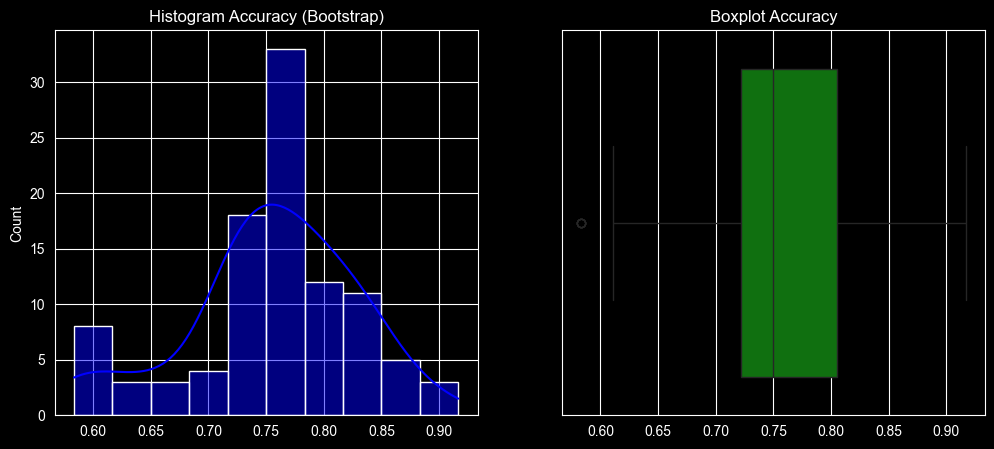

95% Przedział ufności dla Accuracy: [0.583, 0.876]
Średnie Accuracy: 0.755


In [7]:
#Zadanie 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

data = load_wine()
X = data.data
y = data.target
n_bootstrap = 100
scores = []
for i in range(n_bootstrap):
    X_boot, y_boot = resample(X, y, replace=True)
    X_train, X_test, y_train, y_test = train_test_split(X_boot, y_boot, test_size=0.2)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)
    scores.append(acc)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(scores, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Histogram Accuracy (Bootstrap)')
sns.boxplot(x=scores, ax=ax[1], color='green')
ax[1].set_title('Boxplot Accuracy')
plt.show()
lower = np.percentile(scores, 2.5)
upper = np.percentile(scores, 97.5)
print(f"95% Przedział ufności dla Accuracy: [{lower:.3f}, {upper:.3f}]")
print(f"Średnie Accuracy: {np.mean(scores):.3f}")

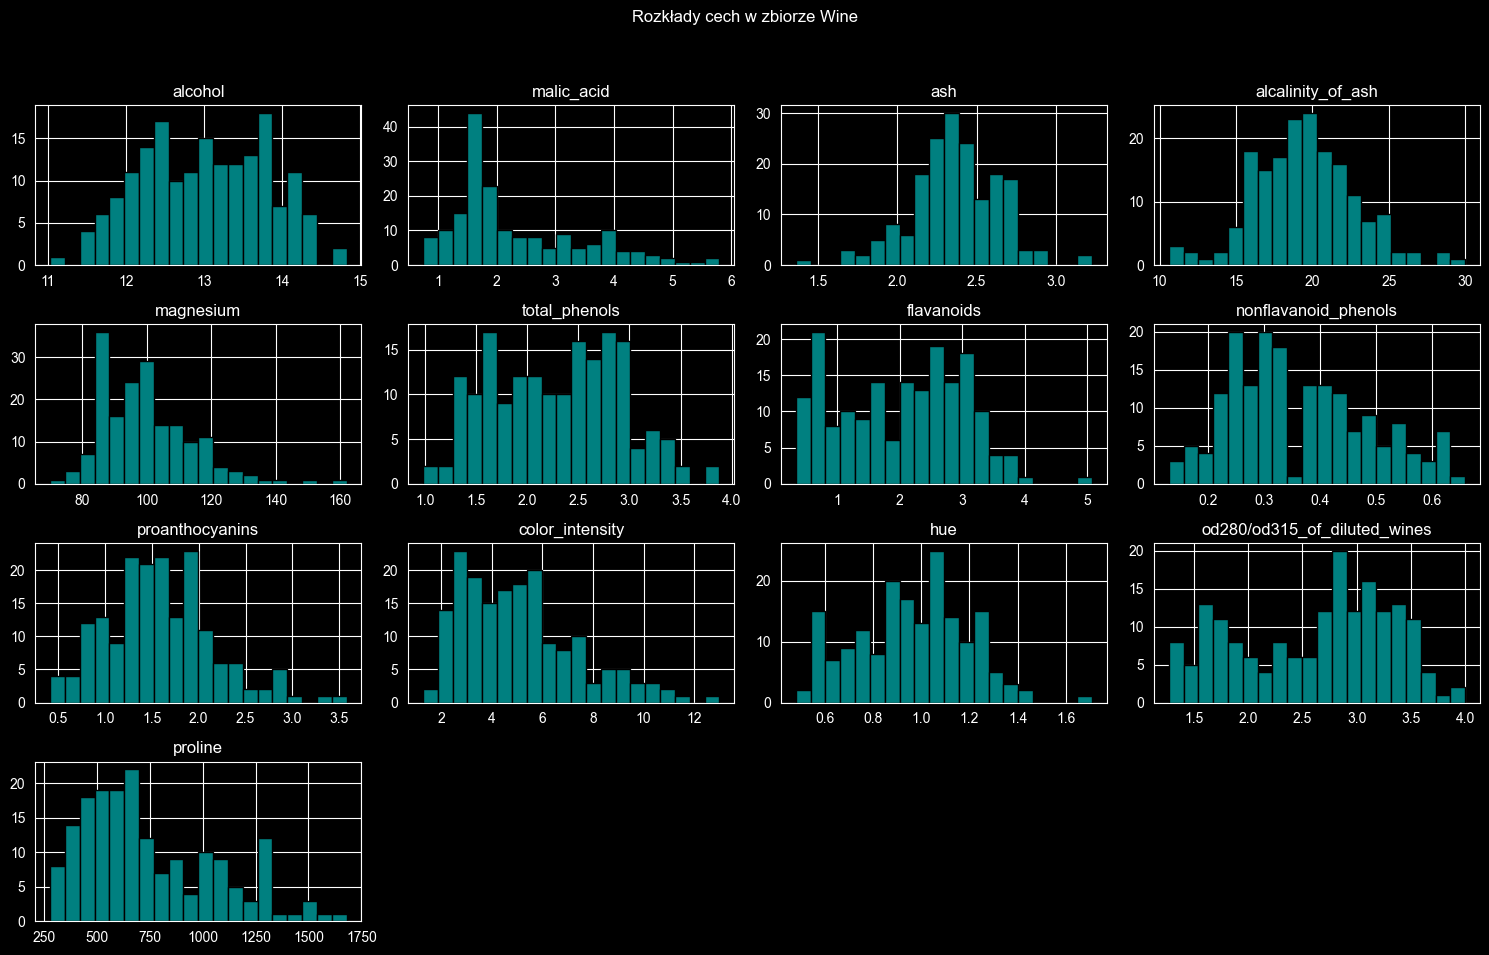

Cechy o rozkładzie zbliżonym do normalnego:  ['alcalinity_of_ash', 'ash', 'proline']
Pozostałe cechy:  ['alcohol', 'malic_acid', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines']


In [8]:
#Zadanie 2
df = pd.DataFrame(X, columns=data.feature_names)
df.hist(figsize=(15, 10), bins=20, color='teal', edgecolor='black')
plt.suptitle("Rozkłady cech w zbiorze Wine")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
cechy_normalne = [
    'alcalinity_of_ash',
    'ash',
    'proline'
]
cechy_pozostale = [
    'alcohol', 'malic_acid', 'magnesium',
    'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines'
]
print("Cechy o rozkładzie zbliżonym do normalnego: ", cechy_normalne)
print("Pozostałe cechy: ", cechy_pozostale)

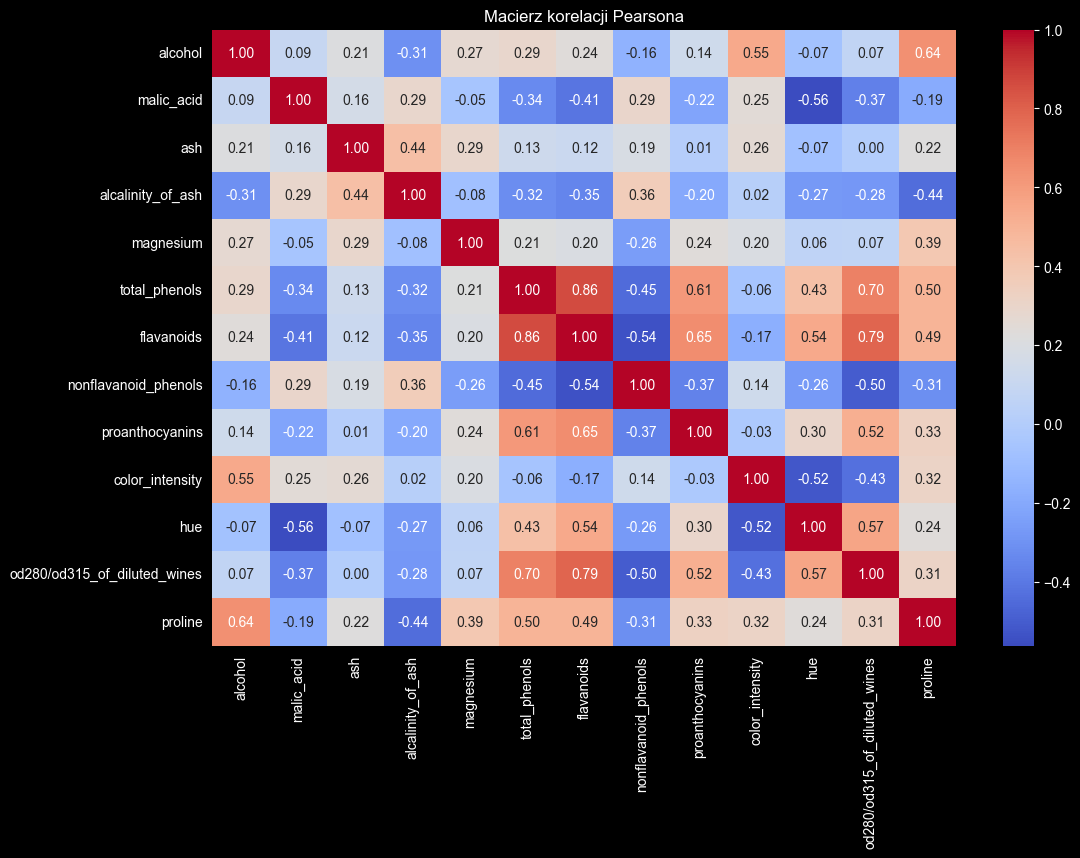

In [9]:
#Zadanie 3
plt.figure(figsize=(12, 8))
pearson_corr = df.corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji Pearsona")
plt.show()

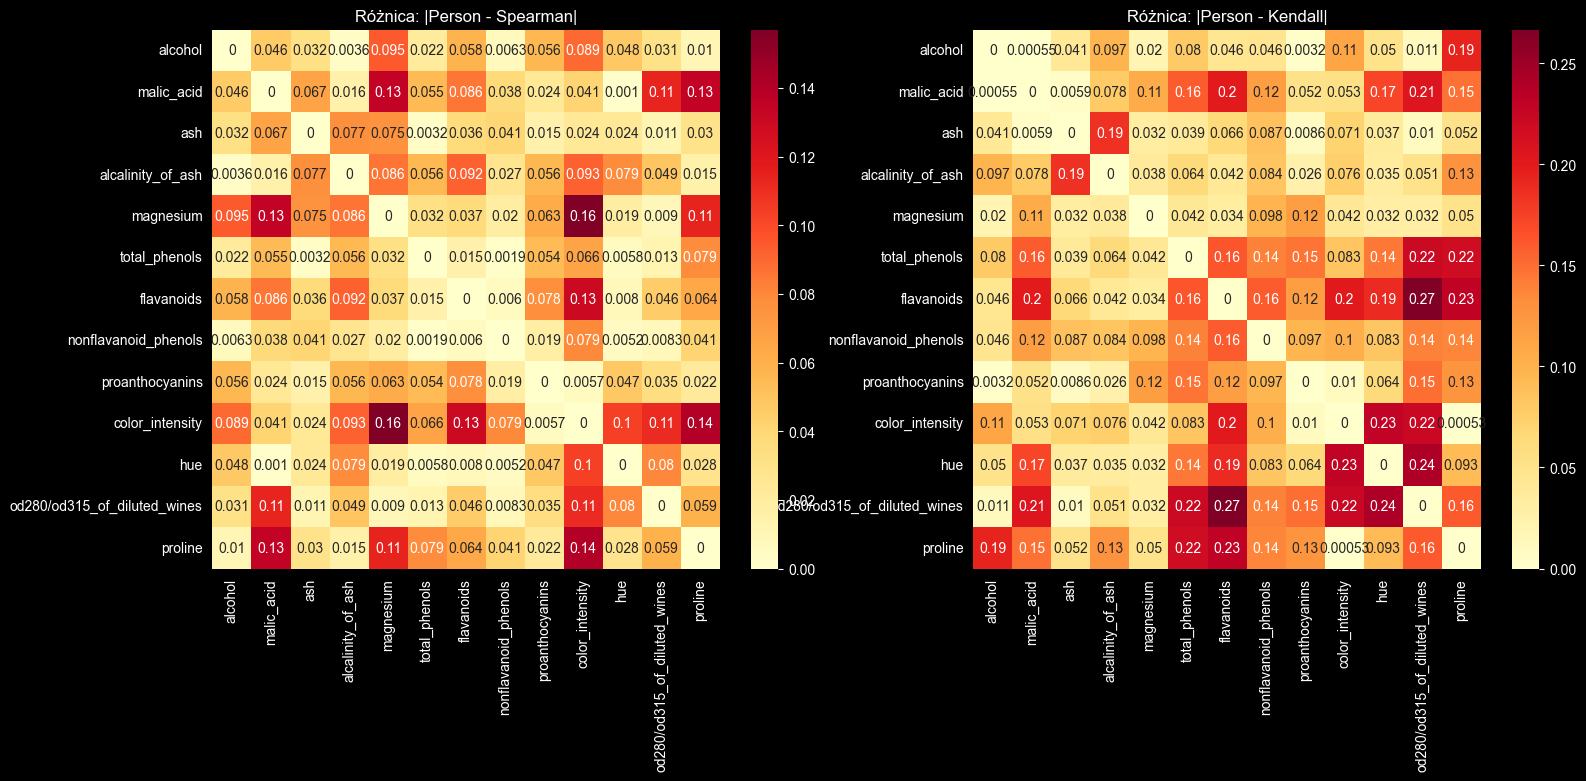

In [10]:
#Zadanie 4
from scipy.stats import spearmanr, kendalltau
spearman_corr = df.corr(method='spearman')
kendall_corr = df.corr(method='kendall')
diff_pearson_spearman = np.abs(pearson_corr.values - spearman_corr.values)
diff_pearson_kendall = np.abs(pearson_corr.values - kendall_corr.values)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(diff_pearson_spearman, annot=True, xticklabels=df.columns, yticklabels=df.columns, ax=ax[0], cmap='YlOrRd')
ax[0].set_title("Różnica: |Person - Spearman|")
sns.heatmap(diff_pearson_kendall, annot=True, xticklabels=df.columns, yticklabels=df.columns, ax=ax[1], cmap='YlOrRd')
ax[1].set_title("Różnica: |Person - Kendall|")
plt.show()

Kolekcja cech z klasą (Spearman): 
alcalinity_of_ash               0.569792
nonflavanoid_phenols            0.474205
malic_acid                      0.346913
color_intensity                 0.131170
ash                            -0.053988
magnesium                      -0.250498
alcohol                        -0.354167
proanthocyanins                -0.570648
proline                        -0.576383
hue                            -0.616570
total_phenols                  -0.726544
od280/od315_of_diluted_wines   -0.743787
flavanoids                     -0.854908
Name: target, dtype: float64
Usuwane cechy: ['ash', 'color_intensity', 'magnesium']
Średnie Accuracy (Pełny zbiór): 0.755
Średnie Accuracy (Zredukowany zbiór): 0.738


C:\Users\astap\AppData\Local\Temp\ipykernel_1460\1400852613.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([scores, scores_reduced], labels= ['Pełny zbiór', 'Zredukowany zbiór'])


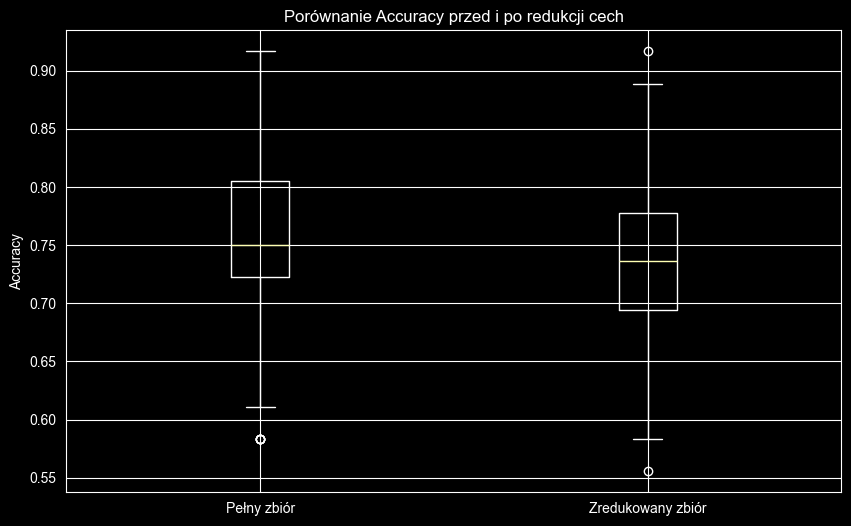

In [11]:
#Zadanie 5
df_full = df.copy()
df_full['target'] = y
target_corr = df_full.corr(method='spearman')['target'].drop('target').sort_values(ascending=False)
print("Kolekcja cech z klasą (Spearman): ")
print(target_corr)
lowest_3_features = target_corr.abs().sort_values().head(3).index.tolist()
print(f"Usuwane cechy: {lowest_3_features}")
X_reduced = df.drop(columns=lowest_3_features).values
scores_reduced = []
for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_reduced, y, replace=True)
    X_train, X_test, y_train, y_test = train_test_split(X_boot, y_boot, test_size=0.2)
    knn_red = KNeighborsClassifier(n_neighbors=5)
    knn_red.fit(X_train, y_train)
    scores_reduced.append(knn_red.score(X_test, y_test))
print(f"Średnie Accuracy (Pełny zbiór): {np.mean(scores):.3f}")
print(f"Średnie Accuracy (Zredukowany zbiór): {np.mean(scores_reduced):.3f}")
plt.figure(figsize=(10, 6))
plt.boxplot([scores, scores_reduced], labels= ['Pełny zbiór', 'Zredukowany zbiór'])
plt.title("Porównanie Accuracy przed i po redukcji cech")
plt.ylabel("Accuracy")
plt.show()